## Exploratory Data Analysis

El análisis exploratorio de datos tiene como objetivo comprender la estructura, características y relaciones presentes en el conjunto de datos del Titanic. A través de este análisis, se busca identificar patrones relevantes, detectar valores faltantes y analizar la distribución de las variables, con el fin de obtener información útil que permita entender qué factores influyeron en la supervivencia de los pasajeros.

In [448]:

import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [449]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [450]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [451]:
# Se observa la presencia de valores faltantes en el dataset, especialmente en las columnas "Age" y "Cabin". Esto podría afectar el análisis y la construcción de modelos predictivos, por lo que se deben considerar estrategias para manejar estos valores faltantes, como la imputación o la eliminación de filas/columnas con demasiados valores faltantes.
df["Age"].fillna(df["Age"].median(), inplace=True)

df.drop("Cabin", axis=1, inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\alons\AppData\Local\Temp\ipykernel_29432\1170587611.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\alons\AppData\Local\Temp\ipykernel_29432\1170587611.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [452]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

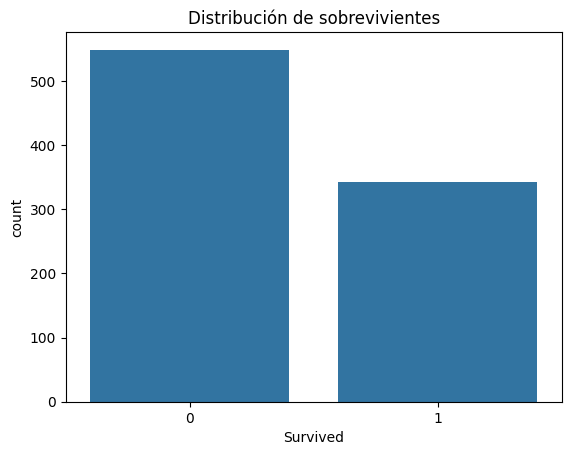

In [453]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Survived", data=df)
plt.title("Distribución de sobrevivientes")
plt.show()

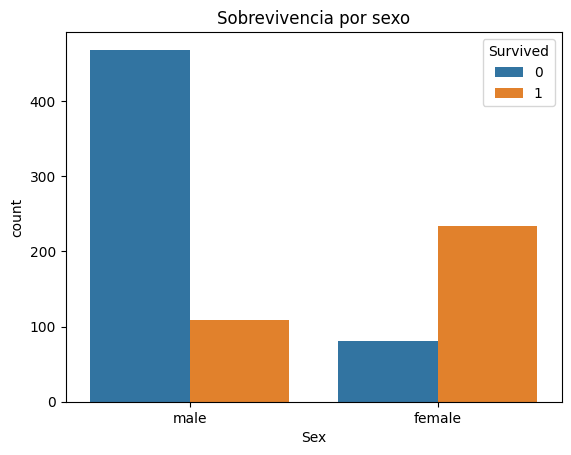

In [454]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Sobrevivencia por sexo")
plt.show()

In [455]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


Se observa que las mujeres presentan una tasa de supervivencia significativamente mayor que los hombres. Mientras que aproximadamente el 74% de las mujeres sobrevivieron, solo cerca del 19% de los hombres lograron sobrevivir.

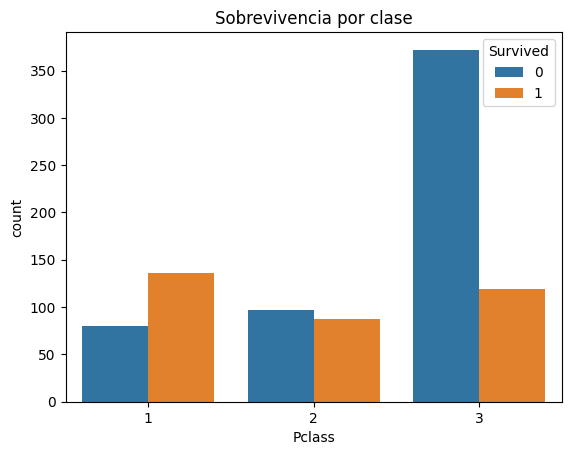

In [456]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Sobrevivencia por clase")
plt.show()

Se puede notar que hay un leve número mayor de sobrevivientes de clase 1 con los de la clase 2 y 3, y también existe un mayor número de no sobrevientes de clase 3 en comparación con la clase 1 y 2.

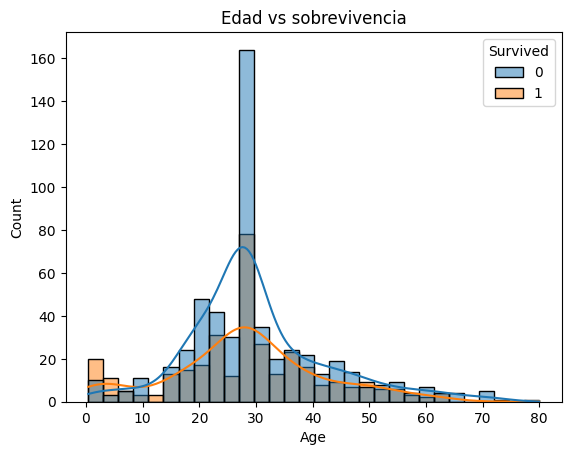

In [457]:
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Edad vs sobrevivencia")
plt.show()

In [458]:
bins = [0, 12, 18, 30, 50, 80]
labels = ["Niños", "Adolescentes", "Jóvenes", "Adultos", "Mayores"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

df["AgeGroup"].value_counts()

AgeGroup
Jóvenes         447
Adultos         241
Adolescentes     70
Niños            69
Mayores          64
Name: count, dtype: int64

In [459]:
pd.crosstab(df["AgeGroup"], df["Survived"])

Survived,0,1
AgeGroup,,
Niños,29,40
Adolescentes,40,30
Jóvenes,299,148
Adultos,139,102
Mayores,42,22


La mayor edad de sobrevivencia está entre los 29 y 30 años, y los no sobrevivientes también están en ese rango, por lo que se puede notar es que había un mayor número de pasajeros de esa edad. La mayoría de los pasajeros se concentra en el grupo de jóvenes, seguido por adultos. Los grupos de niños, adolescentes y mayores presentan menor cantidad de pasajeros en comparación.

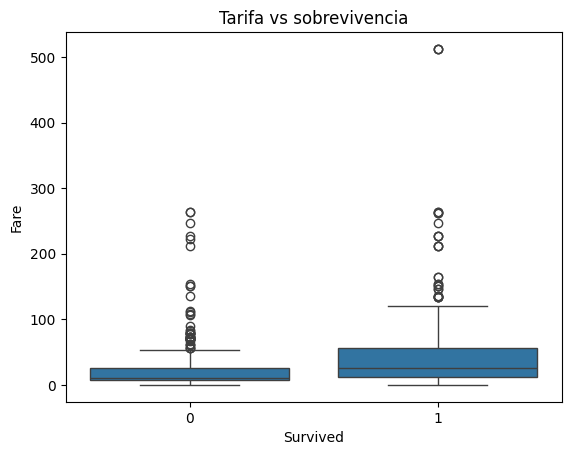

In [460]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Tarifa vs sobrevivencia")
plt.show()

La distribución de la edad muestra que tanto los sobrevivientes como los no sobrevivientes se concentran principalmente en el rango entre 29 y 30 años, lo que sugiere que este grupo etario representaba una mayor proporción de los pasajeros a bordoyexplica que tanto sobrevivientes como no sobrevivientes se agrupen en ese rango etario.

En cuanto a la clase socioeconómica, se observa que los pasajeros de primera clase presentan una mayor proporción de sobrevivientes en comparación con las clases segunda y tercera. Por otro lado, la mayor cantidad de no sobrevivientes corresponde a pasajeros de tercera clase, lo que indica una desventaja asociada a esta condición.

Respecto al género, se evidencia una clara diferencia en las tasas de supervivencia, donde los hombres presentan un mayor número de fallecidos, mientras que las mujeres muestran una mayor proporción de sobrevivientes. Esto sugiere que el género fue un factor determinante en la probabilidad de supervivencia por ende, el género y la edad influyeron en la supervivencia, destacando que mujeres y niños tuvieron mayores probabilidades de sobrevivir, lo que sugiere la aplicación de criterios de prioridad durante la evacuación.